# Students Exam Performance dataset - Regressão Logística - 3 classes

## Importação das bibliotecas

In [224]:
%matplotlib inline
import os
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


from IPython import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Dataset: Leitura, normalização e visualização dos dados

In [225]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrsimple07/student-exam-performance-prediction")

# Carrega o dataset para um DataFrame do pandas
df = pd.read_csv(os.path.join(path, 'student_exam_data.csv'))
print(df.head())

# As duas primeiras colunas são as features (X) e a última é o target (Y)
X = df[['Study Hours', 'Previous Exam Score']].values
y = df['Pass/Fail'].values

Using Colab cache for faster access to the 'student-exam-performance-prediction' dataset.
   Study Hours  Previous Exam Score  Pass/Fail
0     4.370861            81.889703          0
1     9.556429            72.165782          1
2     7.587945            58.571657          0
3     6.387926            88.827701          1
4     2.404168            81.083870          0


# Dividindo Dataset em Treinamento E Validação

In [226]:
# separa treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# opcional, mas ajuda a treinar melhor: padronizar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [227]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 2)
(100, 2)
(400,)
(100,)


### Prepara os dados para o PyTorch

In [228]:
# converte para tensores do PyTorch
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor  = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)   # shape (N,1)
y_test_tensor  = torch.FloatTensor(y_test).view(-1, 1)

In [229]:
y_train_tensor

tensor([[1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
      

In [230]:
X_train_tensor

tensor([[ 1.1654,  0.4718],
        [-1.3439,  0.1282],
        [-0.7095, -1.1803],
        [ 0.5219, -0.5419],
        [-1.6334, -1.2136],
        [-1.3861, -1.2374],
        [ 0.0919, -1.1729],
        [ 0.4249, -1.1341],
        [ 0.8478, -0.1272],
        [-1.2814,  0.0794],
        [ 0.6648, -0.8593],
        [-0.0314,  1.0842],
        [-1.5455, -0.2440],
        [ 0.9390, -0.0705],
        [ 1.5297, -0.6981],
        [-0.5534,  0.1876],
        [ 1.5447,  0.1905],
        [-1.6003,  1.1426],
        [-1.0588, -0.7393],
        [-1.5666, -0.9075],
        [ 0.5133,  1.5670],
        [ 0.6245, -1.3141],
        [ 0.1516,  1.0946],
        [-0.0479,  0.8944],
        [-0.0039,  1.1355],
        [-0.3695,  1.0682],
        [-0.5845,  1.6023],
        [ 1.3174, -1.2361],
        [ 1.0486, -0.0920],
        [-0.8546, -0.1280],
        [-1.1123,  1.7810],
        [ 1.0156, -1.4197],
        [-1.6408,  0.6093],
        [ 1.0222,  1.2466],
        [ 1.5306, -1.6347],
        [-1.0273, -1

## Treinamento

### Definindo o modelo de Regressão Logística

In [231]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        # camada linear: 2 → 1 (duas features, saída escalar)
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        # NÃO aplicamos sigmoid aqui (vamos usar BCEWithLogitsLoss)
        out = self.linear(x)
        return out

In [232]:
input_dim = 2  # Study Hours, Previous Exam Score
model = LogisticRegression(input_dim)

In [233]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

### Laço principal de treinamento da Regressão Logística

In [234]:
num_epochs = 1000

for epoch in range(num_epochs):
    # forward
    outputs = model(X_train_tensor)              # logits
    loss = criterion(outputs, y_train_tensor)    # calcula a perda

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # a cada 100 épocas, mostra loss e acurácia no treino
    if (epoch + 1) % 100 == 0:
        # converte logits em probabilidade e depois em classe (0/1)
        probs = torch.sigmoid(outputs)
        y_pred = (probs >= 0.5).float()
        acc = (y_pred == y_train_tensor).float().mean().item()

        print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {loss.item():.4f}  Acc: {acc:.4f}")


Epoch [100/1000]  Loss: 0.3507  Acc: 0.8725
Epoch [200/1000]  Loss: 0.2985  Acc: 0.8725
Epoch [300/1000]  Loss: 0.2804  Acc: 0.8700
Epoch [400/1000]  Loss: 0.2715  Acc: 0.8700
Epoch [500/1000]  Loss: 0.2664  Acc: 0.8700
Epoch [600/1000]  Loss: 0.2632  Acc: 0.8700
Epoch [700/1000]  Loss: 0.2610  Acc: 0.8700
Epoch [800/1000]  Loss: 0.2596  Acc: 0.8700
Epoch [900/1000]  Loss: 0.2585  Acc: 0.8700
Epoch [1000/1000]  Loss: 0.2578  Acc: 0.8700


## Avaliação

In [235]:
model.eval()  # modo avaliação

with torch.no_grad():
    logits_test = model(X_test_tensor)
    probs_test  = torch.sigmoid(logits_test)
    y_pred_test = (probs_test >= 0.5).float()

    test_acc = (y_pred_test == y_test_tensor).float().mean().item()

print(f"Acurácia no conjunto de teste: {test_acc:.4f}")


Acurácia no conjunto de teste: 0.8600



### Matriz de confusão

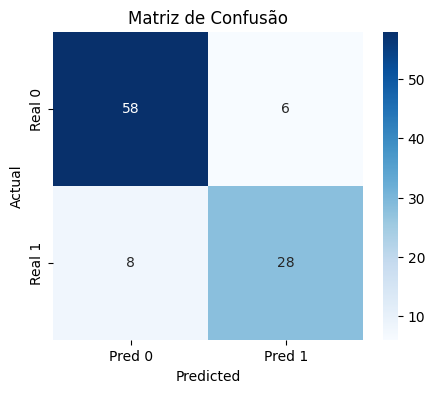

In [236]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

matrix_confusao = confusion_matrix(y_test_tensor.numpy(), y_pred_test.numpy())

plt.figure(figsize=(5,4))
sns.heatmap(matrix_confusao, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1"],
            yticklabels=["Real 0","Real 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matriz de Confusão")
plt.show()

## Principais aprendizados

Nesta atividade, pude aplicar uma regressão logística binária em PyTorch para prever se um estudante passa ou falha no exame com base em duas variáveis: horas de estudo e nota anterior. O processo envolveu preparar o dataset, normalizar as entradas, criar um modelo simples usando nn.Linear, treinar a rede com BCEWithLogitsLoss e avaliar o desempenho no conjunto de teste.

Também pude praticar métricas importantes, como acurácia e matriz de confusão, entendendo melhor como o modelo toma decisões e onde comete erros. Testei alguns ajustes como diferentes otimizadores, taxas de aprendizado e número de épocas, constatando que o modelo alcançou cerca de 86% de acurácia como melhor resultado.